IMPORTING REQUIRED MODULES

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

# MANUAL INSPECTION
DATA DIRTINESS
- age has missing values -5 rows(on programmatic assessment)
- region has missing values -3 rows (on programmatic assessment)

In [ ]:
df=pd.read_csv(r'insurance_data.csv')

In [ ]:
df.info()

WE COULD HAVE CHANGED THE DATATYPE OF AGE COLUMN BUT SINCE SOME VALUES ARE MISSING WE CANNOT FILL IT UP ALTHOUGH WE CAN DROP IT AS ONLY 5 ROWS ARE THERE 

# CATEGORIZING THE COLUMNS
numerical-index,patientid,age,bmi,bloodpressure,claim

categorical-gender,diabetic,smoker,region,children

In [ ]:
df['children'].value_counts()

In [ ]:
df.duplicated().sum()

# UNIVARIATE ANALYSIS ON AGE COLUMN
## conclusions
- all 18 year old (min age) were males
- all 60 year olds(max age) were females
- age column is almost normally distributed
- age has no outlier
- all 53 year olds(the grp with least members) were females
- 5 age rows have no values

In [ ]:
df['age'].describe()

In [ ]:
df.query("age==18")
#all 18 year olds were male

In [ ]:
df.query("age==60")
#all 60 year(max age) olds were females

In [ ]:
df['age'].skew() #almost normally distributed

In [ ]:
df['age'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='age')

In [ ]:
sns.boxplot(data=df, y='age')
plt.show()

In [ ]:
sns.violinplot(data=df, y='age')
plt.show()

In [ ]:
df['age'].isnull().sum()

In [ ]:
df['age'].value_counts()

In [ ]:
df.query('age==53')
#this is the age with least members and all are females

In [ ]:
df.query('age==38')

In [ ]:
df.query('age==47')

# UNIVARIATE ANALYSIS ON BMI COLUMN
## CONCLUSION
- THE PERSON WITH MAX BMI AND MIN BMI BOTH ARE MALES 
- THE DATA IS NORMALLY DISTRIBUTED
- THERE ARE SOME OUTLIERS
- NO NULL VALUES

In [ ]:
df['bmi'].describe()

In [ ]:
df.query('bmi==16')

In [ ]:
df.query('bmi==53.1')

In [ ]:
df['bmi'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bmi')

In [ ]:
df.bmi.skew()

In [ ]:
sns.boxplot(data=df,x='bmi')

In [ ]:
df.query('bmi>45')
#these are the outliers although they don't have any issues with them

In [ ]:
df['bmi'].value_counts()

In [ ]:
df.query('bmi==33.3')

In [ ]:
df['bmi'].duplicated().sum()

# UNIVARIATE ANALYSIS ON BLOODPRESSURE COLUMN
### CONCLUSIONS
- those with highest bloodpressure 140 had very high claims above 35k
- there were outliers above 118 bloodpressure and they also had very high claims
- the bloodpressure column is positively skewed

In [ ]:
df['bloodpressure'].describe()

In [ ]:
df.query('bloodpressure==80')

In [ ]:
df.query('bloodpressure==140')
#the people with 140 blood pressure had very high claims above 35k

In [ ]:
df['bloodpressure'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bloodpressure')

In [ ]:
sns.boxplot(data=df,y='bloodpressure')

In [ ]:
df.query('bloodpressure>118')
#there were outliers above 118 and all of them had very high claim

In [ ]:
df['bloodpressure'].skew()

In [ ]:
df['bloodpressure'].value_counts()

In [ ]:
df['bloodpressure'].isnull().sum()

# UNIVARIATE ANALYSIS ON CLAIM
### CONCLUSIONS
- the least claim is 1121.87 which is by a male
- the highest claim is by a female at 63770.43 who is a smoker
- the data is positively skewed
- there are outliers in this data i.e claims above 35k and on inspection we find that most of them were smokers only 3 weren't smokers and they were females (pid-->1210,1223)
- also when we check those claims above 75 percentile most of them were smokers 

In [ ]:
df['claim'].describe()

In [ ]:
df.query('claim==1121.87')

In [ ]:
df.query('claim==63770.43')

In [ ]:
df.claim.plot(kind='hist')

In [ ]:
df.claim.skew()

In [ ]:
sns.kdeplot(data=df,x='claim')

In [ ]:
sns.boxplot(data=df,y='claim')

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.query('claim > 35000')

In [ ]:
df.claim.value_counts()

In [ ]:
df.claim.isnull().sum()

In [ ]:
df.query('claim>16604.305')['smoker'].value_counts()

In [ ]:
df.query('claim > 35000')['smoker'].value_counts()

# UNIVARIATE ANALYSIS ON CATEGORICAL COLUMNS

## UNIVARIATE ANALYSIS ON GENDER COLUMN
### CONCLUSION
- almost equal no of males and females
- we cannot access normality because there are only two entries

In [ ]:
df.gender.value_counts()

In [ ]:
df.gender.value_counts().plot(kind='bar')

In [ ]:
sns.kdeplot(df.gender.value_counts())

In [ ]:
sns.histplot(df['gender'].value_counts(), kde=True)

In [ ]:
df['gender'].value_counts().plot(kind='pie',autopct='%0.1f%%')

## UNIVARIATE ANALYSIS ON DIABETIC COLUMN
### CONCLUSION
- no null values and almost equal no of diabetic and non diabetic people

In [131]:
df.diabetic.value_counts()

diabetic
No     698
Yes    642
Name: count, dtype: int64

<Axes: xlabel='diabetic'>

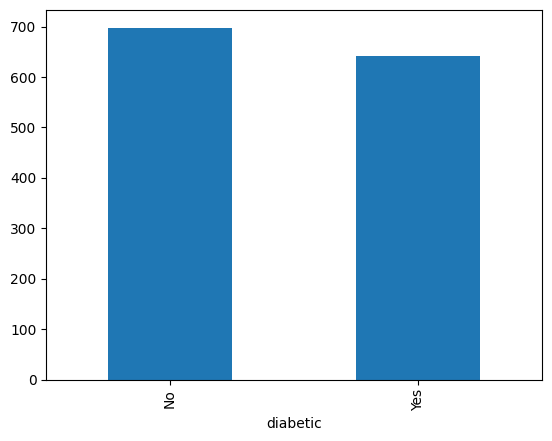

In [132]:
df.diabetic.value_counts().plot(kind='bar')

<Axes: >

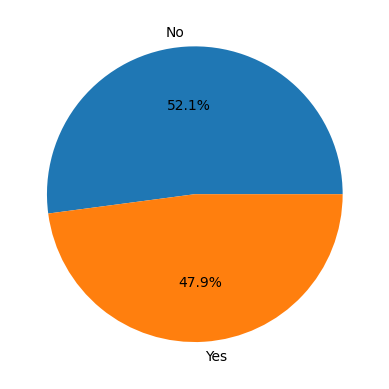

In [133]:
df['diabetic'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [134]:
df.diabetic.isnull().sum()

np.int64(0)

## UNIVARIATE ANALYSIS ON SMOKER COLUMN
### CONCLUSION
- no null values 
- mostly non smokers are there in the dataset

In [135]:
df.smoker.value_counts()

smoker
No     1066
Yes     274
Name: count, dtype: int64

In [136]:
df.smoker.isnull().sum()

np.int64(0)

<Axes: xlabel='smoker'>

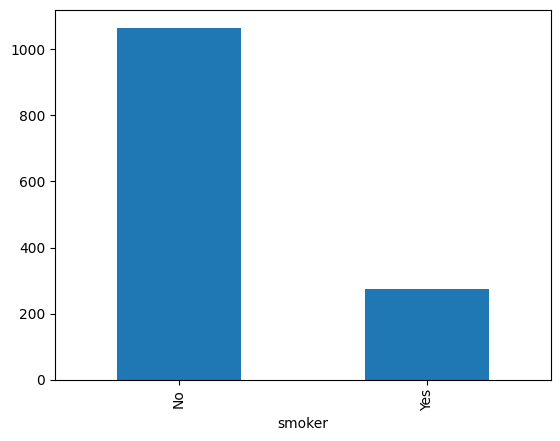

In [137]:
df.smoker.value_counts().plot(kind='bar')

<Axes: >

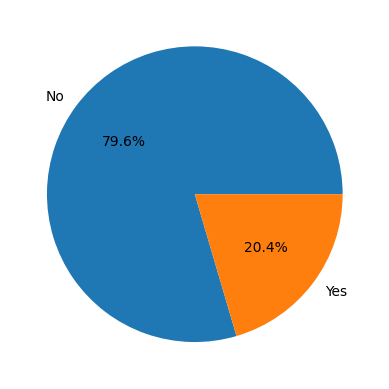

In [144]:
df.smoker.value_counts().plot(kind='pie',autopct='%0.1f%%')

## UNIVARIATE ANALYSIS ON REGION COLUMN
### CONCLUSION
- three values 
- there are four regions 
- southeast 33.1%
- northeast 17.3%
- southwest 23.5%
- northwest 26.1%

In [138]:
df.region.isnull().sum()

np.int64(3)

In [139]:
df.region.value_counts()

region
southeast    443
northwest    349
southwest    314
northeast    231
Name: count, dtype: int64

<Axes: xlabel='region'>

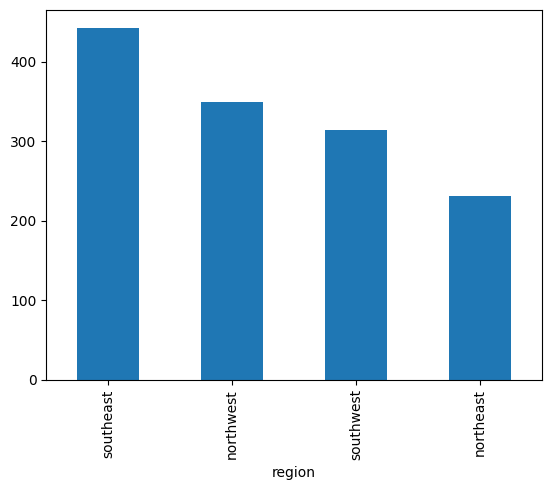

In [140]:
df.region.value_counts().plot(kind='bar')

<Axes: >

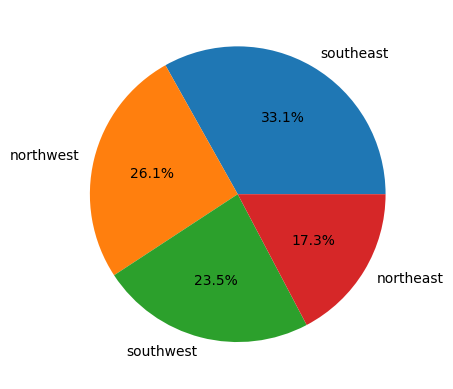

In [143]:
df.region.value_counts().plot(kind='pie',autopct='%0.1f%%')